# Training a Foundational AI Model based on Hail and Wind Damage

This notebook goes through the full process of training an AI model to detect hail and wind damage using satellite imagery. The notebook is broken down into 3 main sections:

1. Data Collection
2. Data Preparation
3. Training the AI

## Google Colab Setup

This tutorial is designed to be run in [google colab](https://colab.research.google.com/). A couple steps need to be taken before running the notebook.

- Go to "Runtime" -> "Change runtime type" -> Select "T4 GPU"
- Install TerraTorch
    - You will have to restart the session after installing terratorch (it kinda looks like an error) then run the pip install again with the new session

In [35]:
%pip install gdown tensorboard zarr earthaccess folium
%pip install terratorch==1.1.1

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## Local Setup

- Install the packages in this `environment.yml` file 

Import all packages required for the notebook

In [36]:
# Standard library imports
import logging
import warnings
from datetime import datetime, timedelta
from pathlib import Path

# Geospatial data access
import earthaccess

# Data manipulation and analysis
import geopandas as gpd
import numpy as np

# Visualization
import folium
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap

# Raster data handling
import rasterio
from rasterio.features import rasterize
from rasterio.plot import show
from rasterio.transform import from_origin

# Geometry operations
from shapely.geometry import polygon

# Deep learning frameworks
import torch
from torch.utils.data import DataLoader

# Geospatial deep learning
import terratorch
from torchgeo.datamodules import GeoDataModule
from torchgeo.datasets import BoundingBox, IntersectionDataset, RasterDataset
from torchgeo.datasets.utils import stack_samples, unbind_samples
from torchgeo.samplers import GridGeoSampler, RandomGeoSampler

# Training utilities
import lightning.pytorch as pl
from lightning.pytorch.callbacks import LearningRateMonitor
from lightning.pytorch.loggers import TensorBoardLogger

# Data augmentation
import kornia.augmentation as K

# Utilities
import gdown
from IPython.core.debugger import set_trace

# Configuration
warnings.filterwarnings("ignore")
logging.basicConfig(level=logging.ERROR)
logging.getLogger("rasterio").setLevel(logging.ERROR)

# Section 1: Data Collection

We are going to be training the model to recognize damage using satellite data. To do this we need to agragate 2 things: labels and images

- The labels: are used as a source of truth that the model can check against
- The images: This is what we want to use to predict the labels

The end goal is to use images to generate a damage map.

## Labels: The Hail and Wind Damage Swath (HWDS) Event Database

<img src="232157546-2523c7be-47b6-429b-a9d0-7aa90d5096ed.png" alt="Hail and Wind Damage Swath" style="width: 600px; height: auto;"/>

A 21-year climatology (2000-2020) of hail and wind damage swaths derived from daily MODIS imagery and storm reports. A subset of the HWDS database (~60 swaths) will be used for testing that overlaps with period of record of HLS and Sentinel-1.

Hail and wind damage swaths (HWDSs) frequently occur during the warmest months of the growing season throughout the Midwest and Great Plains but are not yet officially documented or tracked like other severe weather impacts (e.g., tornadoes and derechos). The creation of a 21-year HWDS event database using archived daily storm reports and daily true color satellite imagery. Once the database was completed and underwent quality checks, the research team identified spatial and temporal trends from the confirmed swaths.

For more information check out the [github repo](https://github.com/jrbell1/hwds_db).

First is we are going to download and unzip the HWDS Event database from google drive.

In [37]:
hwds_google_drive_id = '1TC7JsbrSGTpS0CEvEbGp9TqtxDjAdLBG'
drive_url = f'https://drive.google.com/uc?id={hwds_google_drive_id}'
filename = '25_hwds_shapefile'

if not Path(f'{filename}.zip').exists():
  gdown.download(drive_url)
  !unzip 25_hwds_shapefile.zip

shp_path = Path(filename) / 'hls_hwds_polygons.shp'

## Load the data using geopandas

 Then use geopandas to load the labels from the shapefile into a [GeoDataFrame](https://geopandas.org/en/stable/docs/reference/api/geopandas.GeoDataFrame.html)

In [38]:
gdf = gpd.read_file(shp_path)

Then pull out a single damage swath that we will train on and plot it to visualize

Explain damage swath, what caused it and when it happened.

In [39]:
swath_id = '97'
swath_gdf = gdf[gdf['swathID'] == swath_id]
swath = swath_gdf.iloc[0]

best_post_date = datetime(year=2019, month=5, day=24) # TODO: Update this to pull best date from gdf 

print(swath['swathDate'])

2019-05-17


## Turn label geometry into raster

For training we are going to turn the damage swath geometry into a raster (geotiff). To accomplish this we are going to use 
[rasterio](https://github.com/rasterio/rasterio). 


Before we generate our label raster we are also going to setup some directories for where our data will go.

In [40]:
data_path = Path.cwd() / 'data' / f'swath_{swath_id}'
hls_path = data_path / 'HLS'
label_path = data_path / 'LABEL'

for data_path in (hls_path, label_path):
    data_path.mkdir(parents=True, exist_ok=True) 

The geometry is currently defined in degrees. Since `pixel_size` and `padding` are specified in meters, the data must be reprojected to a coordinate reference system (CRS) that uses meter-based units.

In [41]:
utm_crs = gdf.estimate_utm_crs()
gdf_crs = gdf.to_crs(utm_crs)

swath_crs_gdf = gdf_crs[gdf_crs['swathID'] == swath_id]

print(f"Degrees: {gdf[gdf['swathID'] == swath_id].geometry.iloc[0]}")
print(f"Meters: { swath_crs_gdf.geometry.iloc[0]}")

pixel_size_meters = 30
padding_meters = 1000


def add_padding_to_bounds(bounds):
    minx, miny, maxx, maxy = bounds
    minx -= padding_meters
    miny -= padding_meters
    maxx += padding_meters
    maxy += padding_meters
    
    return minx, miny, maxx, maxy


def rasterize_swath(selected_swath_gdf):
    selected = selected_swath_gdf.iloc[0]
    geom = selected.geometry
    minx, miny, maxx, maxy = add_padding_to_bounds(geom.bounds)
    
    width = int(np.ceil((maxx - minx) / pixel_size_meters))
    height = int(np.ceil((maxy - miny) / pixel_size_meters))

    transform = from_origin(minx, maxy, pixel_size_meters, pixel_size_meters)

    rasterized = rasterize(
        [(geom, 1)],
        out_shape=(height, width),
        transform=transform,
        fill=0,
        dtype='uint8'
    )

    out_path = label_path / f'swathID_{swath_id}.tif'

    with rasterio.open(
        out_path, 'w',
        driver='GTiff',
        height=height,
        width=width,
        count=1,
        dtype='uint8',
        crs=selected_swath_gdf.crs,
        transform=transform
    ) as dst:
        dst.write(rasterized, 1)
        dst.update_tags(polygon_id=str(swath_id))
    
    return out_path

label_raster = rasterize_swath(swath_crs_gdf)

Degrees: POLYGON ((-103.82973622267627 40.82056688317823, -103.80892756291956 40.825495249962614, -103.78249520302762 40.78615523235567, -103.7599584688333 40.76641287022818, -103.70991239079808 40.763555574421844, -103.67422943236033 40.778445015698026, -103.6344684759705 40.79405022058296, -103.60462877790809 40.81209660196066, -103.57363270444125 40.82816951436132, -103.52573270368572 40.85375876859172, -103.49724934484522 40.869686055316606, -103.48902678423167 40.89380223650517, -103.47092419780199 40.917957945667354, -103.42230031117066 40.9259918511533, -103.38638533427661 40.94861074238901, -103.35989858922301 40.96513230885614, -103.33255544422167 40.96972235806953, -103.31328789862692 40.976720473577984, -103.30568655459388 41.005654435750614, -103.27283077603073 41.03029626967299, -103.23395143806431 41.05548569990481, -103.20657162259494 41.09381744156184, -103.13976487284981 41.145839090953416, -103.10252832381155 41.186361217847946, -103.07186293048596 41.224692959505035,

## Visualize Label Raster

Now that we generated a label raster, lets visualize it.

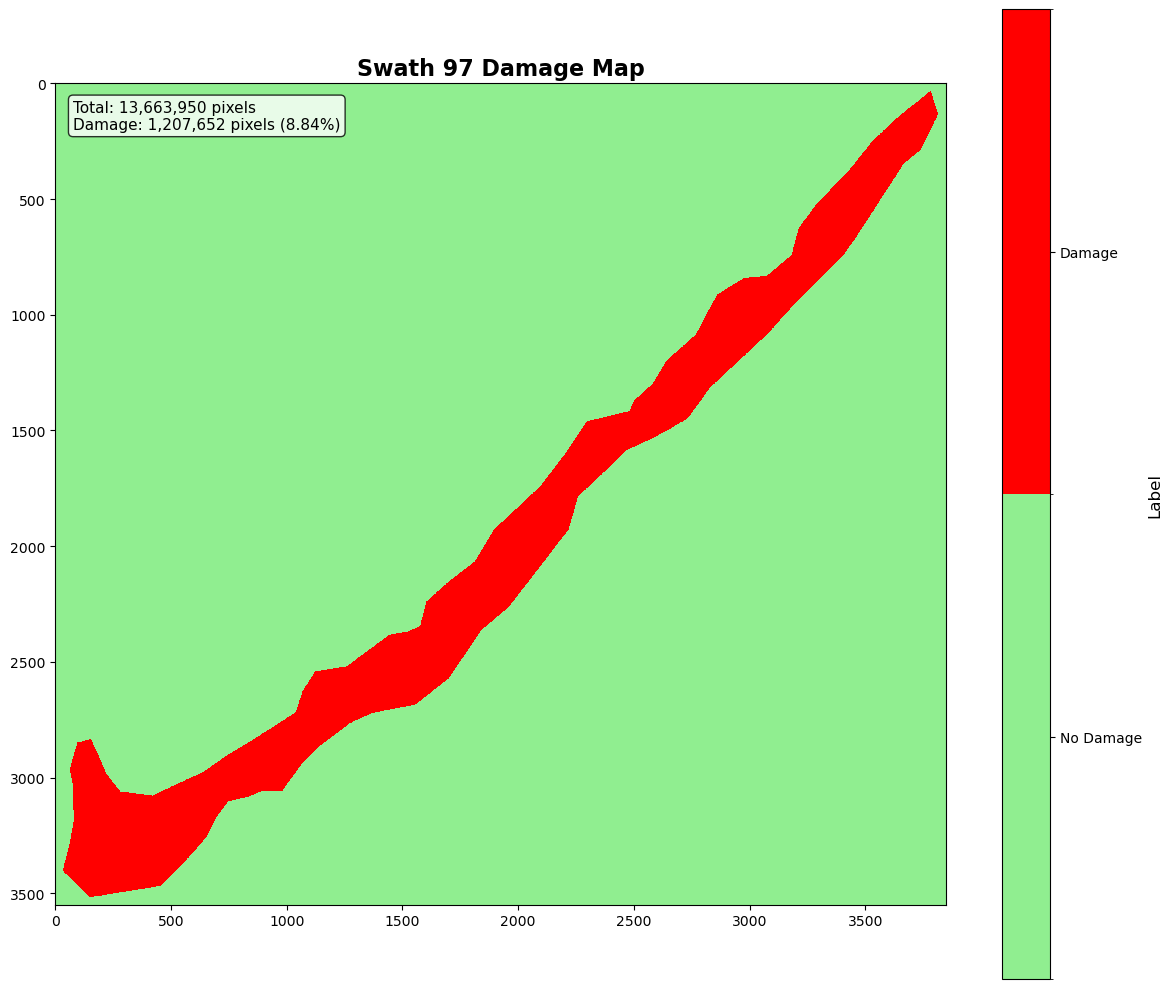

In [42]:
with rasterio.open(label_raster) as src:
    data = src.read(1)
    
    colors = ['lightgreen', 'red']  # 0=no damage, 1=damage
    cmap = mcolors.ListedColormap(colors)
    bounds = [-0.5, 0.5, 1.5]
    norm = mcolors.BoundaryNorm(bounds, cmap.N)
    
    fig, ax = plt.subplots(figsize=(12, 10))
    im = ax.imshow(data, cmap=cmap, norm=norm, interpolation='nearest')
    ax.set_title(f'Swath {swath_id} Damage Map', fontsize=16, fontweight='bold')
    
    cbar = plt.colorbar(im, ax=ax, ticks=[0, 1])
    cbar.set_label('Label', fontsize=12)
    cbar.ax.set_yticklabels(['No Damage', 'Damage'])
    
    total_pixels = data.size
    damage_pixels = np.sum(data == 1)
    damage_pct = (damage_pixels / total_pixels) * 100
    
    textstr = f'Total: {total_pixels:,} pixels\nDamage: {damage_pixels:,} pixels ({damage_pct:.2f}%)'
    props = dict(boxstyle='round', facecolor='white', alpha=0.8)
    ax.text(0.02, 0.98, textstr, transform=ax.transAxes, 
            fontsize=11, verticalalignment='top', bbox=props)
    
    plt.tight_layout()
    plt.show()

# Images: Find and Download HLS data over damage swath 

Our main source of data wil be [Harmonized Landsate and Sentinel-2](https://www.earthdata.nasa.gov/data/projects/hls) (HLS) 

To search for HLS data we will be using [earthaccess](https://earthaccess.readthedocs.io/en/latest/user-reference/api/api/#earthaccess.api.search_data). For HLS there are 2 collections one for Sentinel 2 data ('HLSS30') and one for Landsat data ('HLSL30'). We will only be using the Sentinel 2 since [terramind](https://terrastackai.github.io/terratorch/stable/guide/terramind/#model-versions) has only been trained on S2 data. 

Login should promt you for you earthdata login username and password.

In [43]:
earthaccess.login()

We are searching for data over the damage polygon after the damage event has happened.

In [44]:
geometry = polygon.orient(swath.geometry, sign=1.0)

results = earthaccess.search_data(
    short_name='HLSS30',
    polygon=list(geometry.exterior.coords),
    temporal=(best_post_date, best_post_date + timedelta(days=1))
)

INFO:earthaccess.api:Granules found: 7


## Visualizing Results 

To visualize our results we can compare our damage swath to the extents of the results we got from [earthaccess](https://earthaccess.readthedocs.io/en/latest/user-reference/api/api/). 
For a more in depth search [earthdata search](https://search.earthdata.nasa.gov/search?q=HLSS30) or download and open the hls data inspect it in GIS software. 

In [45]:
geotiff_list = results

def plot_geotiff_extents(results_list, selected_gdf):
    all_lats, all_lons = [], []
    
    m = folium.Map(tiles="OpenStreetMap")
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']

    for i, metadata in enumerate(results_list):
        points = metadata['umm']['SpatialExtent']['HorizontalSpatialDomain']['Geometry']['GPolygons'][0]['Boundary']['Points']
        
        footprint_coords = []
        for point in points:
            lat, lon = point['Latitude'], point['Longitude']
            footprint_coords.append((lat, lon))
            all_lats.append(lat)
            all_lons.append(lon)
        
        tile_color = colors[i % len(colors)]

        folium.Polygon(
            locations=footprint_coords,
            tooltip=f"HLS Tile: {metadata['umm']['GranuleUR']}",
            color=tile_color,
            weight=3,
            fill=True,
            fill_color=tile_color,
            fill_opacity=0.3
        ).add_to(m)
        
    folium.GeoJson(
        selected_gdf.to_json(),
        style_function=lambda x: {
            'fillColor': '#8c564b', 
            'color': '#8c564b',
            'weight': 4,
            'fillOpacity': 0.5
        },
        tooltip=folium.features.GeoJsonTooltip(fields=['swathID', 'swathDate'], aliases=['Swath ID:', 'Date:'], localize=True)
    ).add_to(m)
    
    if all_lats and all_lons:
        map_bounds = [[min(all_lats), min(all_lons)], [max(all_lats), max(all_lons)]]
        m.fit_bounds(map_bounds)

    folium.LayerControl().add_to(m)
    
    return m

In [46]:
final_map = plot_geotiff_extents(results, swath_gdf)
final_map

## Download Data

For training we are going to focus on one event at a time. So data will organized by event and then by data type `HLS` or `LABEL`.

In [47]:
files = earthaccess.download(
    results,
    local_path=hls_path
)

INFO:earthaccess.store: Getting 7 granules, approx download size: 1.46 GB


QUEUEING TASKS | :   0%|          | 0/126 [00:00<?, ?it/s]

INFO:earthaccess.store:File HLS.S30.T13TGG.2019144T173909.v2.0.B11.tif already downloaded
INFO:earthaccess.store:File HLS.S30.T13TGG.2019144T173909.v2.0.B10.tif already downloaded
INFO:earthaccess.store:File HLS.S30.T13TGG.2019144T173909.v2.0.B01.tif already downloaded
INFO:earthaccess.store:File HLS.S30.T13TGG.2019144T173909.v2.0.B03.tif already downloaded
INFO:earthaccess.store:File HLS.S30.T13TGG.2019144T173909.v2.0.Fmask.tif already downloaded
INFO:earthaccess.store:File HLS.S30.T13TGG.2019144T173909.v2.0.B05.tif already downloaded


PROCESSING TASKS | :   0%|          | 0/126 [00:00<?, ?it/s]

INFO:earthaccess.store:File HLS.S30.T13TGG.2019144T173909.v2.0.VZA.tif already downloaded
INFO:earthaccess.store:File HLS.S30.T13TGG.2019144T173909.v2.0.B07.tif already downloaded
INFO:earthaccess.store:File HLS.S30.T13TGG.2019144T173909.v2.0.B06.tif already downloaded
INFO:earthaccess.store:File HLS.S30.T13TGG.2019144T173909.v2.0.B02.tif already downloaded
INFO:earthaccess.store:File HLS.S30.T13TGG.2019144T173909.v2.0.B12.tif already downloaded
INFO:earthaccess.store:File HLS.S30.T13TGG.2019144T173909.v2.0.VAA.tif already downloaded
INFO:earthaccess.store:File HLS.S30.T13TGG.2019144T173909.v2.0.B09.tif already downloaded
INFO:earthaccess.store:File HLS.S30.T13TGG.2019144T173909.v2.0.B8A.tif already downloaded
INFO:earthaccess.store:File HLS.S30.T13TGG.2019144T173909.v2.0.B04.tif already downloaded
INFO:earthaccess.store:File HLS.S30.T13TGG.2019144T173909.v2.0.B08.tif already downloaded
INFO:earthaccess.store:File HLS.S30.T13TGG.2019144T173909.v2.0.SZA.tif already downloaded
INFO:earth

COLLECTING RESULTS | :   0%|          | 0/126 [00:00<?, ?it/s]

# Section 2: Data Preperation

Now that we have all the data, we need to setup some code to load the data in a format we can use for training. For this we will use a [PyTorch Lightning DataModule](https://lightning.ai/docs/pytorch/stable/data/datamodule.html). This encapsulates all the steps to process and use the data for training. It constis of:

- Datasets: What the data files look like and how to load them
- Transforms: Operations that we do to the data before training (Normalization, Flips/Rotations)
- Samplers: How to pick data when training (Random, Gridded)
- DataLoader: Load data from a dataset and batch samples

## Setup Datasets 

To load our data we our going to be using a pytorch domain libary called [TorchGeo](https://github.com/torchgeo/torchgeo). We're going to use [RasterDataset](https://torchgeo.readthedocs.io/en/stable/api/datasets.html#torchgeo.datasets.RasterDataset) as a base class for our HLS data and our Label data.

In [65]:
from typing import Any


class HLSDataset(RasterDataset):
    """
    HLS dataset using TorchGeo's RasterDataset base class.
    
    Example file name:
        HLS.S30.T13TFF.2019144T173909.v2.0.B08.tif

    Bands:
        B01 ->  COASTAL
        B02 ->  BLUE
        B03 ->  GREEN
        B04 ->  RED
        B05 ->  REDEDGE1
        B06 ->  REDEDGE2
        B07 ->  REDEDGE3
        B08 ->  NIR
        B8A ->  NIR08
        B09 ->  NIR09
        B11 ->  SWIR16
        B12 ->  SWIR22
    """
    
    filename_glob = "HLS.*.tif"
    filename_regex = r"^HLS\.(?P<sensor>[SL])30\.(?P<tile>T\w+)\.(?P<date>\d+T\d+)\.v\d+\.\d+\.(?P<band>B\w+|SZA|SAA|VZA|VAA)\.tif$"
    date_format = '%Y%d%mT%H%M%S'
    
    separate_files = True
    is_image = True
    
    all_bands = ("B01", "B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B09", "B11", "B12")
    rgb_bands = ('B04', 'B03', 'B02')
    
    def plot(
            self, 
            sample: dict[str, Any],
            show_titles: bool = True,
            suptitle: str | None = None,
            normalized = False
        ):
        rgb_indices = []
        for band in self.rgb_bands:
            rgb_indices.append(self.bands.index(band))

        image = sample['image'][rgb_indices].permute(1, 2, 0)
        # DN = 10000 * REFLECTANCE
        # https://docs.sentinel-hub.com/api/latest/data/sentinel-2-l2a/
        if not normalized:
            image = torch.clamp(image / 10000, min=0, max=1)

        fig, ax = plt.subplots(1, 1, figsize=(4, 4))

        ax.imshow(image)
        ax.axis('off')

        if show_titles:
            ax.set_title('Image')

        if suptitle is not None:
            plt.suptitle(suptitle)

        return fig


class LabelDataset(RasterDataset):
    filename_glob = "swathID_*.tif"
    is_image = False

    def plot(self, sample):
        mask = sample['mask']
        
        if mask.dim() == 3:  # (C, H, W)
            mask = mask[0]
        elif mask.dim() == 4:  # (B, C, H, W)
            mask = mask[0, 0]
        
        mask = mask.numpy()
        
        fig, ax = plt.subplots()
        ax.imshow(mask, cmap='viridis')
        ax.axis('off')

        ax.set_title('Damage Label')
        
        return fig


## Data Normilization

A common practice when training AI models is to normailze data. To do this we need to calculate the mean and standard deviation for our HLS data. To not have to load all the HLS data into memory at a time we are using a fancy [Parallel variance algorithm](https://jonisalonen.com/2013/deriving-welfords-method-for-computing-variance/) to correctly calculate standard deviation.

In [66]:
hls_dataset = HLSDataset(
    paths=hls_path,
    bands=('B01', 'B02', 'B03', 'B04', 'B05', 'B06', 
               'B07', 'B08', 'B8A', 'B09', 'B11', 'B12')
)

def calculate_mean_and_std(band_tifs: list[Path]) -> tuple[float, float]:
    count, mean, M2 = 0, 0, 0
    
    for band_tif in band_tifs:
        with rasterio.open(band_tif) as src:
            band_data = src.read(1).flatten()
            
            batch_count = len(band_data)
            batch_mean = np.mean(band_data)
            batch_var = np.var(band_data)
            
            # Parallel variance algorithm 
            delta = batch_mean - mean
            mean = (count * mean + batch_count * batch_mean) / (count + batch_count)
            M2 = M2 + batch_var * batch_count + delta**2 * count * batch_count / (count + batch_count)
            count += batch_count
    
    variance = M2 / count
    std = np.sqrt(variance)
    
    return mean, std


HLS_MEAN, HLS_STD = [], []

print('Band, Mean, Std')
for band in hls_dataset.bands:
    mean, std = calculate_mean_and_std([f for f in hls_dataset.files if f'{band}.tif' in f])
    print(band, f'{mean:.2f}', f'{std:.2f}')
    HLS_MEAN.append(mean)
    HLS_STD.append(std)

Band, Mean, Std
B01 565.89 1137.23
B02 674.88 1145.97
B03 986.92 1176.77
B04 1152.91 1217.22
B05 1461.42 1229.23
B06 1998.67 1280.78
B07 2211.27 1327.95
B08 2310.64 1347.11
B8A 2446.05 1352.69
B09 1153.80 1119.03
B11 3112.19 1412.86
B12 2223.23 1309.65


## Setup DataLoader

To load the data into a format that a gpu can use, were going to use a pytorch [dataloader](https://docs.pytorch.org/docs/stable/data.html#torch.utils.data.DataLoader). DataLoaders combine a sampler and a dataset to load the data into batchs of a given size. The `collate_fn` is used to structure the data, for now we are using a `torchgeo` utility function.

### Sampler
`Torchgeo` gives has 2 samplers that we will use in this notebook:
- [RandomGeoSampler](https://torchgeo.readthedocs.io/en/latest/api/samplers.html#random-geo-sampler): Sample `length` number of patchs of a given `size`
- [GridGeoSampler](https://torchgeo.readthedocs.io/en/latest/api/samplers.html#grid-geo-sampler): Sample patchs in a grid. 

### Datasets

For datasets we will use the HLS dataset and later we will create a Label dataset.

In [67]:
patch_size = 224

sampler = RandomGeoSampler(
    hls_dataset,
    size=patch_size,
    length=10,
)

dataloader = DataLoader(
    hls_dataset,
    sampler=sampler,
    batch_size=2,
    collate_fn=stack_samples,
)

Now we test that we can load data. To plot a loaded sample we need to remove the batch dimension. `unbind_samples` is a torchgeo util that does just that.

5
Batch: dict_keys(['crs', 'bounds', 'image']), Image Shape: torch.Size([2, 12, 224, 224])
Single Sample: dict_keys(['crs', 'bounds', 'image']), Image Shape: torch.Size([12, 224, 224])
Single Sample: dict_keys(['crs', 'bounds', 'image']), Image Shape: torch.Size([12, 224, 224])


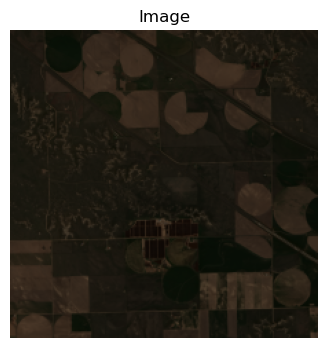

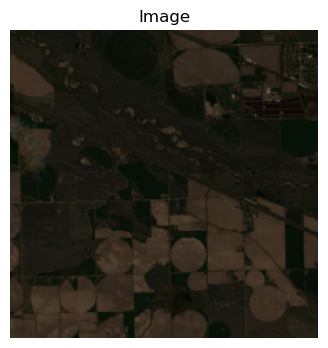

In [68]:
print(len(dataloader))

for batch in dataloader:
    batch_shape = batch['image'].shape # [B, C, W, H]
    print(f"Batch: {batch.keys()}, Image Shape: {batch_shape}")

    samples = unbind_samples(batch)
    # fig, axs = plt.subplots(nrows=1, ncols=len(samples))

    for i, sample in enumerate(samples):
        sample_shape = sample['image'].shape # [C, W, H]
        print(f"Single Sample: {sample.keys()}, Image Shape: {sample_shape}")

        hls_dataset.plot(sample)

    # train_model(batch) 
    break

## Transformations

Along with loading the data, we also want to apply some transformations to the data before training. We are going to use a library called [Kornia](https://kornia.readthedocs.io/en/stable/get-started/introduction.html), but there are other libraries that can be more or less drop in replacements.

This is where we are going to normilze the data as well as do some flipping. Here is an [article](https://medium.com/@maahip1304/the-complete-guide-to-image-preprocessing-techniques-in-python-dca30804550c) that goes more into why applying these transformations is important.

Everything will be the same as before be this time we are passing the transforms to the `HLSDataset`.

min: -1.2585704326629639
max: 2.1174023151397705


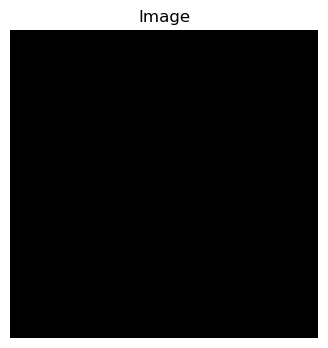

In [69]:
transform = K.AugmentationSequential(
    K.Normalize(HLS_MEAN, HLS_STD),
    K.RandomVerticalFlip(p=0.5),
    K.RandomHorizontalFlip(p=0.5),
    data_keys=None,
    keepdim=True
)

hls_dataset = HLSDataset(
    paths=hls_path,
    bands=('B01', 'B02', 'B03', 'B04', 'B05', 'B06', 
               'B07', 'B08', 'B8A', 'B09', 'B11', 'B12'),
    transforms=transform
)

train_sampler = RandomGeoSampler(
    hls_dataset,
    size=patch_size,
    length=100,
)

dataloader = DataLoader(
    hls_dataset,
    sampler=train_sampler,
    batch_size=2,
    collate_fn=stack_samples,
)

for batch in dataloader:
    sample = unbind_samples(batch)[0]

    print("min:", sample['image'].min().item())
    print("max:", sample['image'].max().item())

    hls_dataset.plot(sample)
    break

The image here is black because the data is normalized instead of being the data values.

## Intersection dataset

During training we need to load both our hls and label data. Luckily `torchgeo` gives us a handy tool to accomplish this called an [intersection dataset](https://torchgeo.readthedocs.io/en/stable/api/datasets.html#torchgeo.datasets.IntersectionDataset).

TODO: 
Take a bit more about an intersection dataset and how they work.
Better labels on min/max printouts
layout graphs horizontily and make them the same size
Show that both image and mask are same shapes



Converting LabelDataset CRS from EPSG:32614 to EPSG:32613


Image Min: -1.7861589193344116
Image Max max: 4.2894511222839355
Mask Min: 0
Mask Max: 0
torch.Size([12, 224, 224])
torch.Size([224, 224])
Image Min: -1.870095133781433
Image Max max: 2.346040725708008
Mask Min: 0
Mask Max: 1
torch.Size([12, 224, 224])
torch.Size([224, 224])


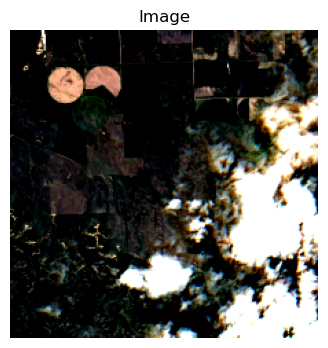

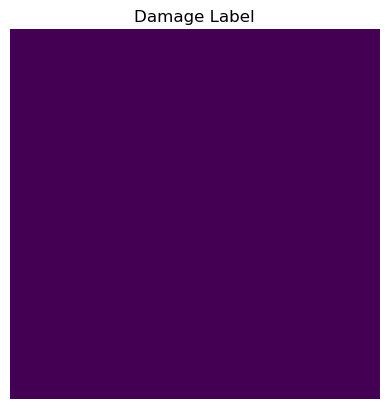

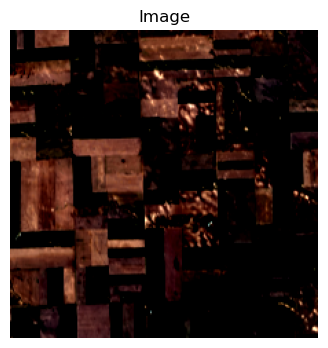

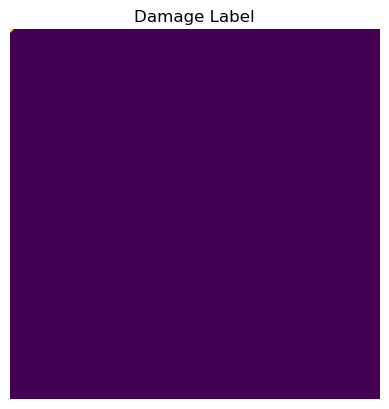

In [70]:
hls_dataset = HLSDataset(
    paths=hls_path,
    bands=('B01', 'B02', 'B03', 'B04', 'B05', 'B06', 
               'B07', 'B08', 'B8A', 'B09', 'B11', 'B12'),
)

label_dataset = LabelDataset(paths=label_path)

dataset = IntersectionDataset(hls_dataset, label_dataset, transforms=transform)

train_sampler = RandomGeoSampler(
    dataset,
    size=patch_size,
    length=1000,
)

dataloader = DataLoader(
    dataset,
    sampler=train_sampler,
    batch_size=2,
    collate_fn=stack_samples,
)

for batch in dataloader:
    # Find a sample with some damage
    if batch['mask'].max() > 0:
        for sample in unbind_samples(batch):
            print("Image Min:", sample['image'].min().item())
            print("Image Max max:", sample['image'].max().item())

            print("Mask Min:", sample['mask'].min().item())
            print("Mask Max:", sample['mask'].max().item())

            print(sample['image'].shape)
            print(sample['mask'].shape)

            hls_dataset.plot(sample, normalized=True)
            label_dataset.plot(sample)
        break

## Setup DataModule 

Putting the pieces together [PyTorch Lightning](https://lightning.ai/docs/pytorch/stable/) has the conecpt of a [DataModule](https://lightning.ai/docs/pytorch/stable/data/datamodule.html). This is a class that is responsible for

- Loading the data (Sometimes this includes downloading also)
- Applying transformations
- Providing a dataloader

In [20]:
class HLSDataModule(GeoDataModule):  
    def __init__(
        self,
        hls_path: str,
        label_path: str,
        batch_size: int = 8,
        patch_size: int = 224,
        train_length: int = 100,
        val_length: int = 20,
        num_workers: int = 2,
    ):
        super().__init__(HLSDataset)
        
        self.hls_path = hls_path
        self.label_path = label_path
        self.batch_size = batch_size
        self.patch_size = patch_size
        self.train_length = train_length
        self.val_length = val_length
        self.num_workers = num_workers
        
        self.train_aug = K.AugmentationSequential(
            K.Normalize(HLS_MEAN, HLS_STD),
            K.RandomVerticalFlip(p=0.5),
            K.RandomHorizontalFlip(p=0.5),
            data_keys=['image', 'mask'],
            keepdim=True,
        )
        
        self.val_aug = K.AugmentationSequential(
            K.Normalize(HLS_MEAN, HLS_STD),
            data_keys=['image', 'mask'],
            keepdim=True,
        )
        
        self.test_aug = self.val_aug
        
    def setup(self, stage=None):
        self.hls_dataset = HLSDataset(
            paths=self.hls_path,
            bands=('B01', 'B02', 'B03', 'B04', 'B05', 'B06', 
                   'B07', 'B08', 'B8A', 'B09', 'B11', 'B12')
        )
        
        self.label_dataset = LabelDataset(paths=self.label_path)
        self.dataset = self.label_dataset & self.hls_dataset
        
        self.train_sampler = RandomGeoSampler(
            self.dataset,
            size=self.patch_size,
            length=self.train_length
        )
        self.val_sampler = RandomGeoSampler(
            self.dataset,
            size=self.patch_size,
            length=self.val_length
        )

        if stage in ['fit', 'validate']:
            self.train_dataset = self.train_dataloader()
            self.val_dataset = self.val_dataloader()

    def terramind_collate_fn(self, batch):
        stacked = stack_samples(batch)
        return {
            'image': {'S2L2A': stacked['image']},  # Nested structure for terramind 
            'mask': stacked['mask'],
            'crs': stacked['crs'],
            'bounds': stacked['bounds']
        }

    def train_dataloader(self):
        return DataLoader(
            self.dataset,
            sampler=self.train_sampler,
            batch_size=self.batch_size,
            collate_fn=self.terramind_collate_fn,
            num_workers=self.num_workers,
        )
    
    def val_dataloader(self):
        return DataLoader(
            self.dataset,
            sampler=self.val_sampler,
            batch_size=self.batch_size,
            collate_fn=self.terramind_collate_fn,
            num_workers=self.num_workers,
        )

    def on_after_batch_transfer(self, batch, dataloader_idx):
        if self.trainer.training:
            aug = self.train_aug
        elif self.trainer.validating or self.trainer.sanity_checking:
            aug = self.val_aug
        else:
            aug = self.test_aug
        
        image = batch['image']['S2L2A']
        mask = batch['mask']
        
        image, mask = aug(image, mask)
        
        batch['image']['S2L2A'] = image
        batch['mask'] = mask
        
        return batch

    # TODO: Clean this up 
    def plot(self, sample, split='val'):
        def plot_binary_mask(ax, mask_data, title, fig):
            if mask_data.dim() == 3:  # (C, H, W)
                mask_data = mask_data[0]
            elif mask_data.dim() == 4:  # (B, C, H, W)
                mask_data = mask_data[0, 0]
                
            mask_np = mask_data.numpy()
            
            colors = ['lightgreen', 'red']  # 0=no damage, 1=damage
            cmap = ListedColormap(colors)
            bounds = [-0.5, 0.5, 1.5]
            norm = BoundaryNorm(bounds, cmap.N)
            
            im = ax.imshow(mask_np, cmap=cmap, norm=norm, interpolation='nearest')
            ax.set_title(title, fontsize=14, fontweight='bold')
            ax.axis('off')
            
            cbar = fig.colorbar(im, ax=ax, ticks=[0, 1], fraction=0.046)
            cbar.set_label(title, fontsize=12)
            cbar.ax.set_yticklabels(['No Damage', 'Damage'])
        
        if 'image' in sample and isinstance(sample['image'], dict):
            standard_sample = {
                'image': sample['image']['S2L2A'],
                'mask': sample['mask']
            }
        else:
            standard_sample = sample
        
        has_prediction = 'prediction' in sample
        num_plots = 3 if has_prediction else 2
        
        fig, axes = plt.subplots(1, num_plots, figsize=(6 * num_plots, 6))
        
        hls_fig = self.hls_dataset.plot(standard_sample)
        hls_ax = hls_fig.axes[0]
        for image in hls_ax.get_images():
            axes[0].imshow(image.get_array())
        axes[0].set_title('HLS RGB Image', fontsize=14, fontweight='bold')
        axes[0].axis('off')
        plt.close(hls_fig)
        
        plot_binary_mask(axes[1], standard_sample['mask'], 'Label', fig)
        
        if has_prediction:
            plot_binary_mask(axes[2], sample['prediction'], 'Prediction', fig)
        
        plt.tight_layout()
        return fig

In [21]:
datamodule = HLSDataModule(
    hls_path=hls_path,
    label_path=label_path,
    batch_size=8
)

datamodule.setup()
dataloader = datamodule.train_dataloader()

Converting HLSDataset CRS from EPSG:32613 to EPSG:32614


13
torch.Size([8, 12, 224, 224])
tensor(805.5687)


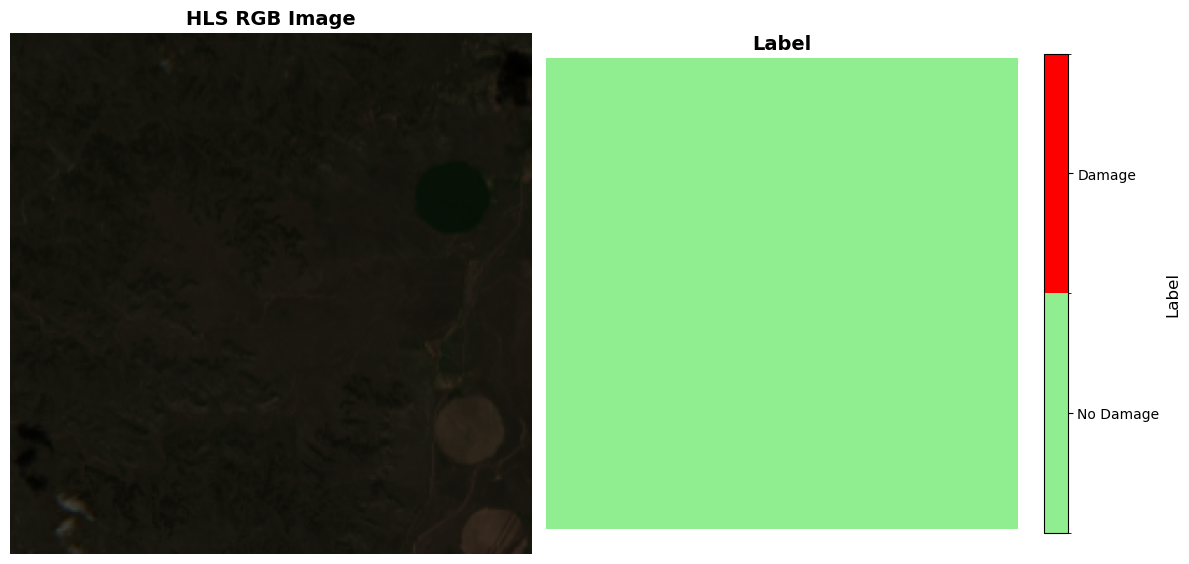

In [22]:
loader_iter = iter(dataloader)
print(len(loader_iter))

batch = next(loader_iter)
print(batch['image']['S2L2A'].shape)
batch_size = batch['image']['S2L2A'].shape[0]

sample = {
    'image': {'S2L2A': batch['image']['S2L2A'][0]},
    'mask': batch['mask'][0]
}
print(sample['image']['S2L2A'].std())

# Create temporary figure from datamodule.plot()
temp_fig = datamodule.plot(sample)

plt.tight_layout()
plt.show()

# Section 3: Training The AI

Now that we have the labels, image and DataModule to load them, we can start training! To do this we need to setup a couple things.

- Model: The weights to train and how those weights are structured
- Trainer: How to perform the training
- TensorBoard: Log and analyze how our training went

## Terratorch

To help us get our model and trainer we our going to be using [TerraTorch](https://github.com/terrastackai/terratorch).  

TODO: 
- talk about terratorch
- talk about/link to info about loss/optimizer/learning-rate 
- talk about head dropout
- talk about lightning tasks
- link to other tutorials

In [23]:
MODALITIES = ['S2L2A']

model = terratorch.tasks.SemanticSegmentationTask(
  model_factory='EncoderDecoderFactory',
  model_args={
      'backbone': 'terramind_v1_base',
      'backbone_pretrained': True,
      'backbone_modalities': MODALITIES,
      'necks': [
          {'name': 'SelectIndices', 'indices': [2, 5, 8, 11]},
          {'name': 'ReshapeTokensToImage', 'remove_cls_token': False},
          {'name': 'LearnedInterpolateToPyramidal'}
      ],
      'decoder': 'UNetDecoder',
      'decoder_channels': [512, 256, 128, 64],
      'head_dropout': 0.1,
      'num_classes': 2,
  },
  loss='dice',
  optimizer='AdamW',
  lr=2e-5,
  ignore_index=-1,
  freeze_backbone=True,
  freeze_decoder=False,
  plot_on_val=True,
  class_names=['no-damage', 'damage'],
)

INFO:httpx:HTTP Request: HEAD https://huggingface.co/ibm-esa-geospatial/TerraMind-1.0-base/resolve/main/TerraMind_v1_base.pt "HTTP/1.1 302 Found"


## Pytorch Lightning

- Talk more about pytorch lightning
- Link to docs

In [24]:

# TensorBoard logger
tb_logger = TensorBoardLogger(
  save_dir='output/terramind_base_hwds/',
  name='tensorboard_logs',
)

# Callbacks
checkpoint_callback = pl.callbacks.ModelCheckpoint(
  dirpath='output/terramind_base_hwds/checkpoints/',
  filename='best-epoch{epoch:02d}-mIoU{val/mIoU:.4f}',
  monitor='val/mIoU',
  mode='max',
  save_top_k=1,
  save_last=True,
  save_weights_only=False,
  auto_insert_metric_name=False,
)

lr_monitor = LearningRateMonitor(logging_interval='step')

trainer = pl.Trainer(
  accelerator='auto',
  strategy='auto',
  precision="16-mixed",
  num_nodes=1,
  logger=tb_logger,
  max_epochs=2,
  log_every_n_steps=5,
  callbacks=[
      checkpoint_callback,
      lr_monitor,
      pl.callbacks.RichProgressBar()
  ],
  default_root_dir='output/terramind_base_hwds/',
)

INFO: Using 16bit Automatic Mixed Precision (AMP)
INFO:lightning.pytorch.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs


## Tensorboard

- talk about tensor board
- talk about plotting on validation
- link to docs

In [26]:
%load_ext tensorboard
%tensorboard --logdir output

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 168051), started 0:00:11 ago. (Use '!kill 168051' to kill it.)

## Fine turning

- talk about putting it all together

In [39]:
trainer.fit(model, datamodule=datamodule)

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Converting HLSDataset CRS from EPSG:32613 to EPSG:32614


┏━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┓
┃   ┃ Name          ┃ Type             ┃ Params ┃ Mode  ┃
┡━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━┩
│ 0 │ model         │ PixelWiseModel   │  102 M │ train │
│ 1 │ criterion     │ DiceLoss         │      0 │ train │
│ 2 │ train_metrics │ MetricCollection │      0 │ train │
│ 3 │ val_metrics   │ MetricCollection │      0 │ train │
│ 4 │ test_metrics  │ ModuleList       │      0 │ train │
└───┴───────────────┴──────────────────┴────────┴───────┘

Trainable params: 15.5 M                                                                                           
Non-trainable params: 87.3 M                                                                                       
Total params: 102 M                                                                                                
Total estimated model params size (MB): 411                                                                        
Modules in train mode: 288                                                                                         
Modules in eval mode: 0

Output()

INFO: `Trainer.fit` stopped: `max_epochs=2` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=2` reached.


TODO: Add next steps and what to do next (analyze results, run more epochs, change samplers, change learning rate)

## Glossary

TODO: Add a glossary with a bunch of links